## Creating confidence from mixing weights

Previously, we have done some experiments on bootstrapping the `z` values to create confidence intervals. But as an afterthought, is might be much easier and also more accurate to create the confidence intervals from the mixing weights directly, as they are not binary and naturally have a distribution so 

### First, we load in the data

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('png', dpi=600)
plt.style.use('smaller.mplstyle')


# Load the data
names = ["10kb", "50kb", "100kb"]
resolutions = [10000, 50000, 100000]
dfs = {}
for name,resolution in zip(names, resolutions):

    y = pd.Series(pd.read_csv(f"../data/eigs/sperm_X.eigs.{resolution}.cis.vecs.tsv", sep="\t")['E1'].values.flatten())
    x = pd.Series(np.arange(0,y.shape[0])*resolution)

    dfs[name] = pd.DataFrame({"start": x, "e1": y})
    dfs[name].dropna(inplace=True)


centromere = (57984683, 69396537)
small_arm = (0, centromere[0])
large_arm = (centromere[1], x.max())
q_small = "start >= @small_arm[0] and start <= @small_arm[1]"
q_large = "start >= @large_arm[0] and start <= @large_arm[1]"



In [37]:
# Example
dfs['50kb'].query(q_small)

,start,e1
56,2800000,-0.075775
57,2850000,-0.419196
58,2900000,-0.154143
59,2950000,-0.280683
60,3000000,-0.305154
...,...,...
1155,57750000,-0.103347
1156,57800000,0.109004
1157,57850000,0.174414
1158,57900000,0.209500


### No bootstrapping

We actually don't have to bootstrap now, as the mixing weights are not binary, but continuous. So we can just use the distribution of the mixing weights to create confidence intervals.

In [38]:
import numpy as np
import arviz as az

trace_z = az.from_netcdf(f"../results/traces/07_hi_res_z_trace.nc")
trace_w = az.from_netcdf(f"../results/traces/07_hi_res_w_trace.nc")

w_stack_z = trace_z.posterior.w.stack(
   sample=["chain", "draw"]
)
w_stack_w = trace_w.posterior.w.stack(
    sample=["chain", "draw"]
)


In [39]:
display(az.summary(trace_z, var_names=["mu", "sigma", "grw_sigma"], round_to=2))
display(az.summary(trace_w, var_names=["mu", "sigma", "grw_sigma"], round_to=2))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[B],-0.26,0.01,-0.28,-0.24,0.0,0.0,635.84,1754.50,1.00
mu[A],0.24,0.01,0.22,0.26,0.0,0.0,536.07,1379.61,1.01
sigma[B],0.33,0.01,0.32,0.34,0.0,0.0,3827.87,5309.53,1.00
sigma[A],0.32,0.01,0.31,0.33,0.0,0.0,1620.19,3825.56,1.00
grw_sigma,0.04,0.00,0.03,0.04,0.0,0.0,4502.68,5030.66,1.00


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[B],-0.26,0.01,-0.28,-0.24,0.0,0.0,7239.49,5670.08,1.0
mu[A],0.24,0.01,0.22,0.26,0.0,0.0,10223.36,5743.50,1.0
sigma[B],0.33,0.01,0.32,0.33,0.0,0.0,8182.18,4857.44,1.0
sigma[A],0.32,0.01,0.31,0.33,0.0,0.0,8728.51,5539.37,1.0
grw_sigma,0.04,0.00,0.03,0.04,0.0,0.0,7060.49,5237.37,1.0


In [40]:
display(w_stack_z, w_stack_w)

<xarray.DataArray 'w' (pos: 5376, sample: 7000)> Size: 301MB
array([[0.50855592, 0.47955529, 0.49533573, ..., 0.48108606, 0.51131858,
        0.49195426],
       [0.50099056, 0.47593478, 0.49390709, ..., 0.48089991, 0.52637216,
        0.47838893],
       [0.50069523, 0.46610216, 0.49810795, ..., 0.46693585, 0.52052264,
        0.46194883],
       ...,
       [0.98721082, 0.99587065, 0.98867181, ..., 0.98920123, 0.99439652,
        0.99105442],
       [0.98639584, 0.99611564, 0.98918505, ..., 0.98895172, 0.99453151,
        0.99120603],
       [0.98627243, 0.99615631, 0.98939814, ..., 0.98889366, 0.99462367,
        0.99146937]], shape=(5376, 7000))
Coordinates:
  * pos      (pos) int64 43kB 278 279 280 281 282 ... 5794 5795 5796 5797 5798
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

<xarray.DataArray 'w' (pos: 5376, sample: 7000)> Size: 301MB
array([[0.48184014, 0.49675812, 0.49042409, ..., 0.49183007, 0.49851813,
        0.49795749],
       [0.48181092, 0.49076683, 0.48691288, ..., 0.49186527, 0.48619251,
        0.48884509],
       [0.47169336, 0.49280828, 0.47282896, ..., 0.48238663, 0.48797053,
        0.48394326],
       ...,
       [0.99605241, 0.95811922, 0.97992979, ..., 0.9450661 , 0.99459494,
        0.9736982 ],
       [0.99586202, 0.95937027, 0.97871481, ..., 0.94241419, 0.99486929,
        0.97453365],
       [0.99610599, 0.95708045, 0.98005666, ..., 0.94130801, 0.99499015,
        0.9749862 ]], shape=(5376, 7000))
Coordinates:
  * pos      (pos) int64 43kB 278 279 280 281 282 ... 5794 5795 5796 5797 5798
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

In [41]:
compare = az.compare({'Z':trace_z, 'W':trace_w}, ic='waic')
compare

/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Z,0,-2027.525447,740.281860,0.000000,1.0,55.349946,0.000000,True,log
W,1,-2149.326265,20.901057,121.800818,0.0,58.300723,6.158294,False,log


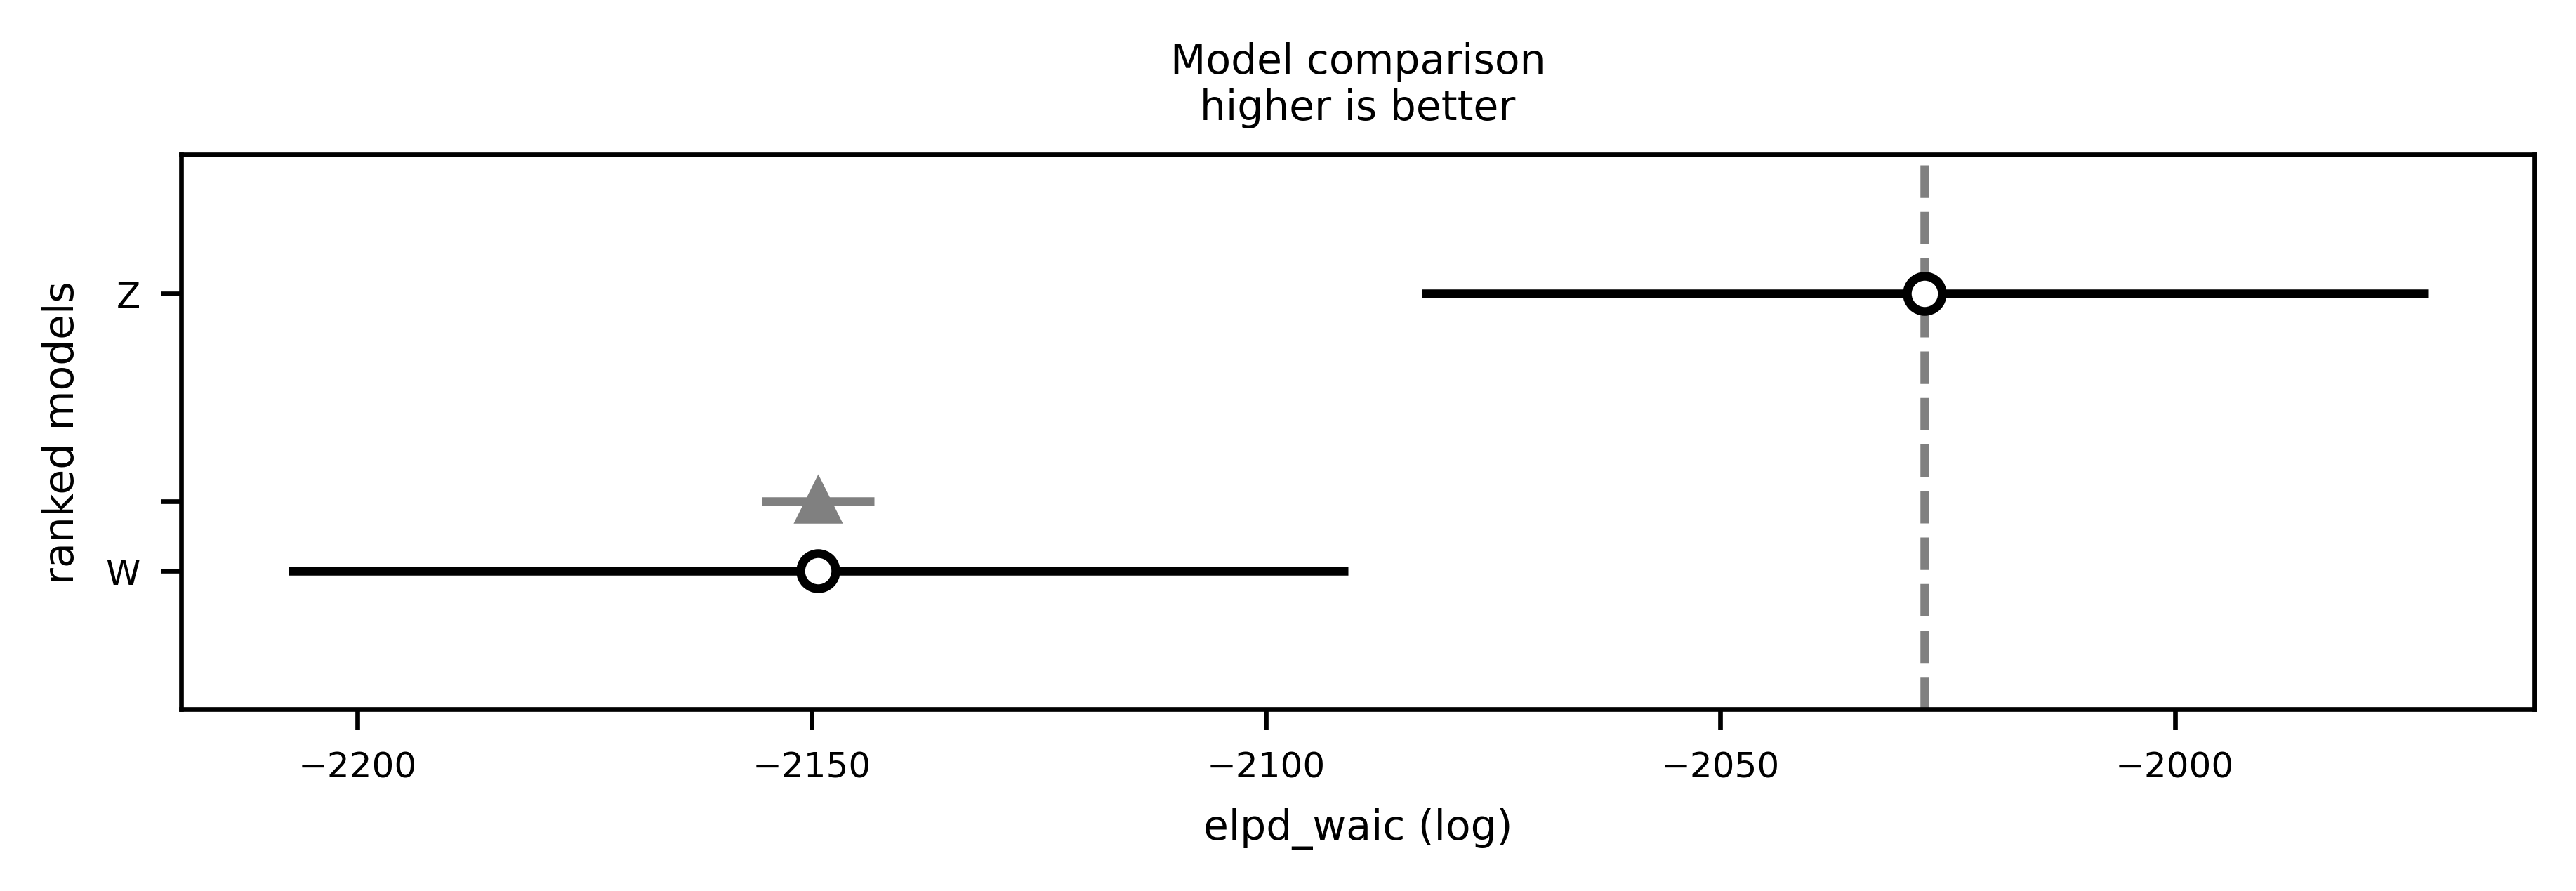

In [42]:
az.plot_compare(compare, plot_ic_diff=True);

So, it seems the model with the latent hard assignment was better after all, based on the `az.compare`. The `weight` column can be losely interpreted as the probability of the model given the data, relative to the other model(s).

In [43]:
# Use the trace directly  in stead of bootstrapping

w_mean = trace_z.posterior["w"].mean(dim=("chain", "draw"))  # shape (8714,)
w_ci_direct = trace_z.posterior["w"].quantile([0.05, 0.95], dim=("chain", "draw"))  # shape (2, 8714)
w_ci_upper_direct = w_ci_direct.sel(quantile=0.05)  # shape (8714,)
w_ci_lower_direct = w_ci_direct.sel(quantile=0.95)  # shape (8714,)


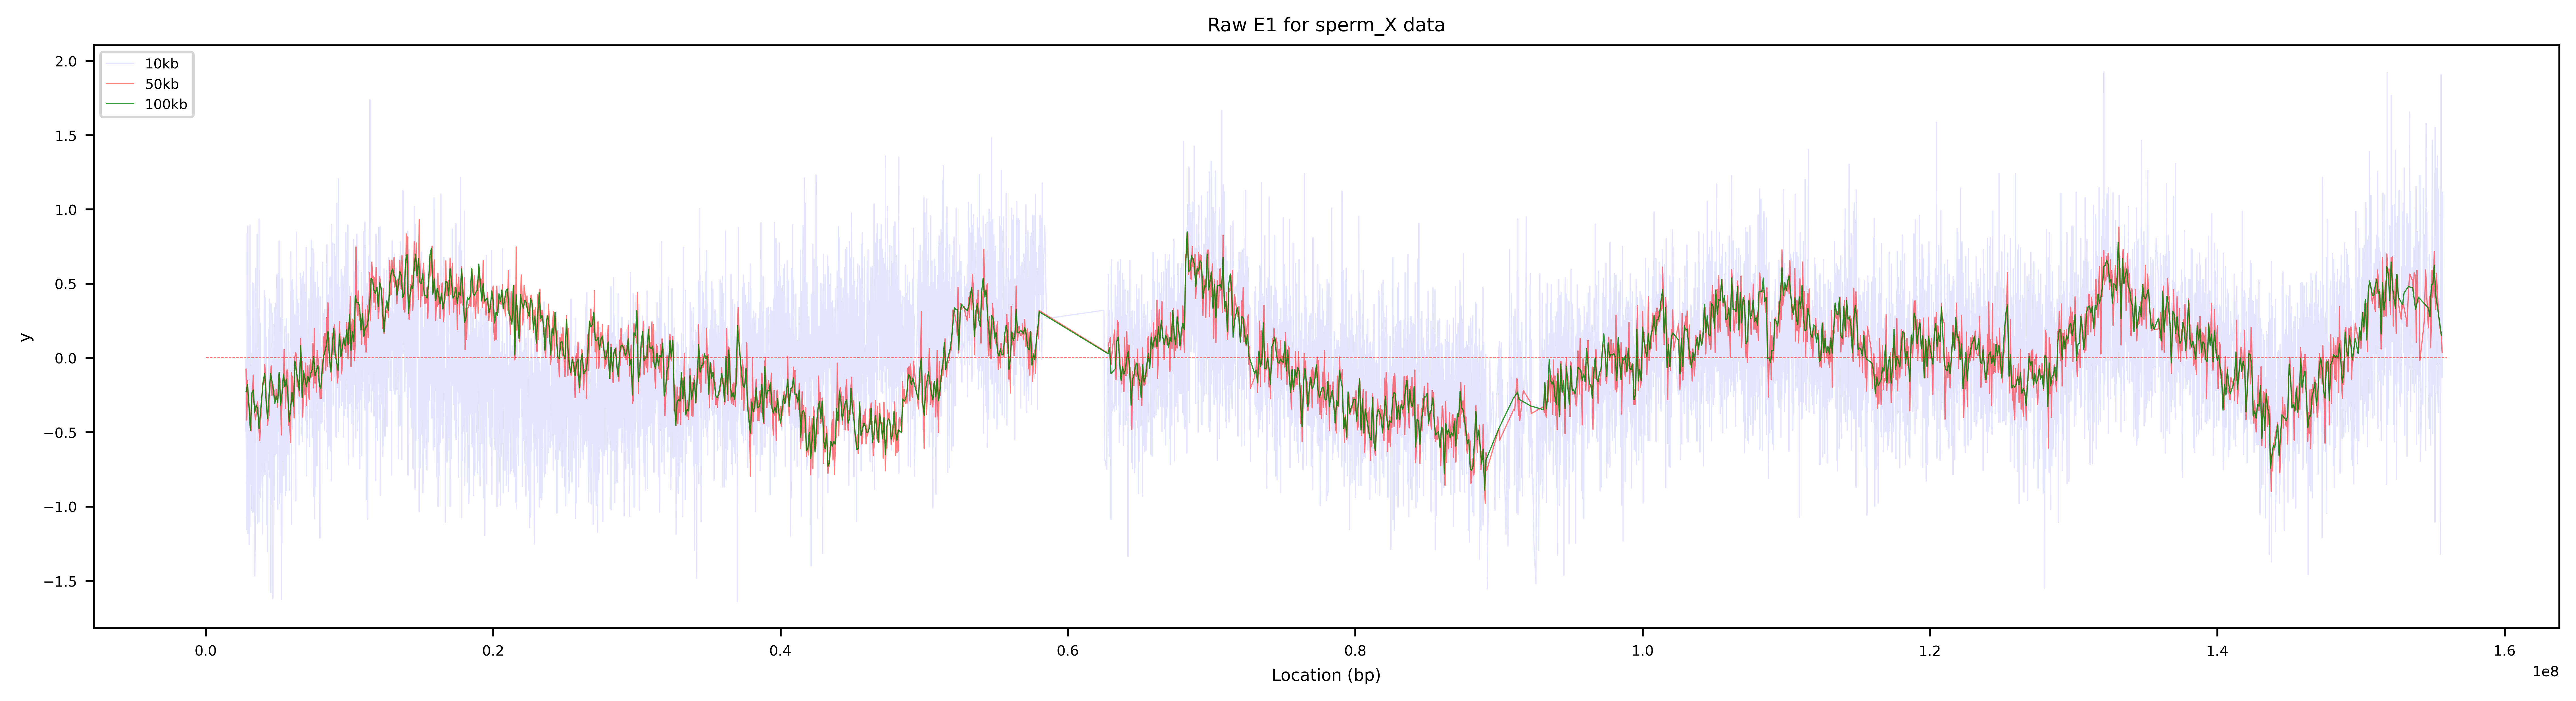

In [44]:
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png', dpi=600)


f, ax = plt.subplots(figsize=(15, 4))

ax.plot('start', 'e1', data = dfs['10kb'], linewidth=0.5, color="blue", label="10kb", alpha=0.1)
ax.plot('start', 'e1', data = dfs['50kb'], linewidth=0.5, color="red", label="50kb", alpha=0.5)
ax.plot('start', 'e1', data = dfs['100kb'], linewidth=0.5, color="green", label="100kb", alpha=0.8)

# Plot the 0.5 line
ax.hlines(0, min(x), max(x), color="red", linestyle="--", linewidth=0.3)

plt.ylabel("y")
plt.xlabel("Location (bp)")
plt.legend(loc='upper left')
plt.title("Raw E1 for sperm_X data")
# # # # # plt#tight_layout()
plt.show()

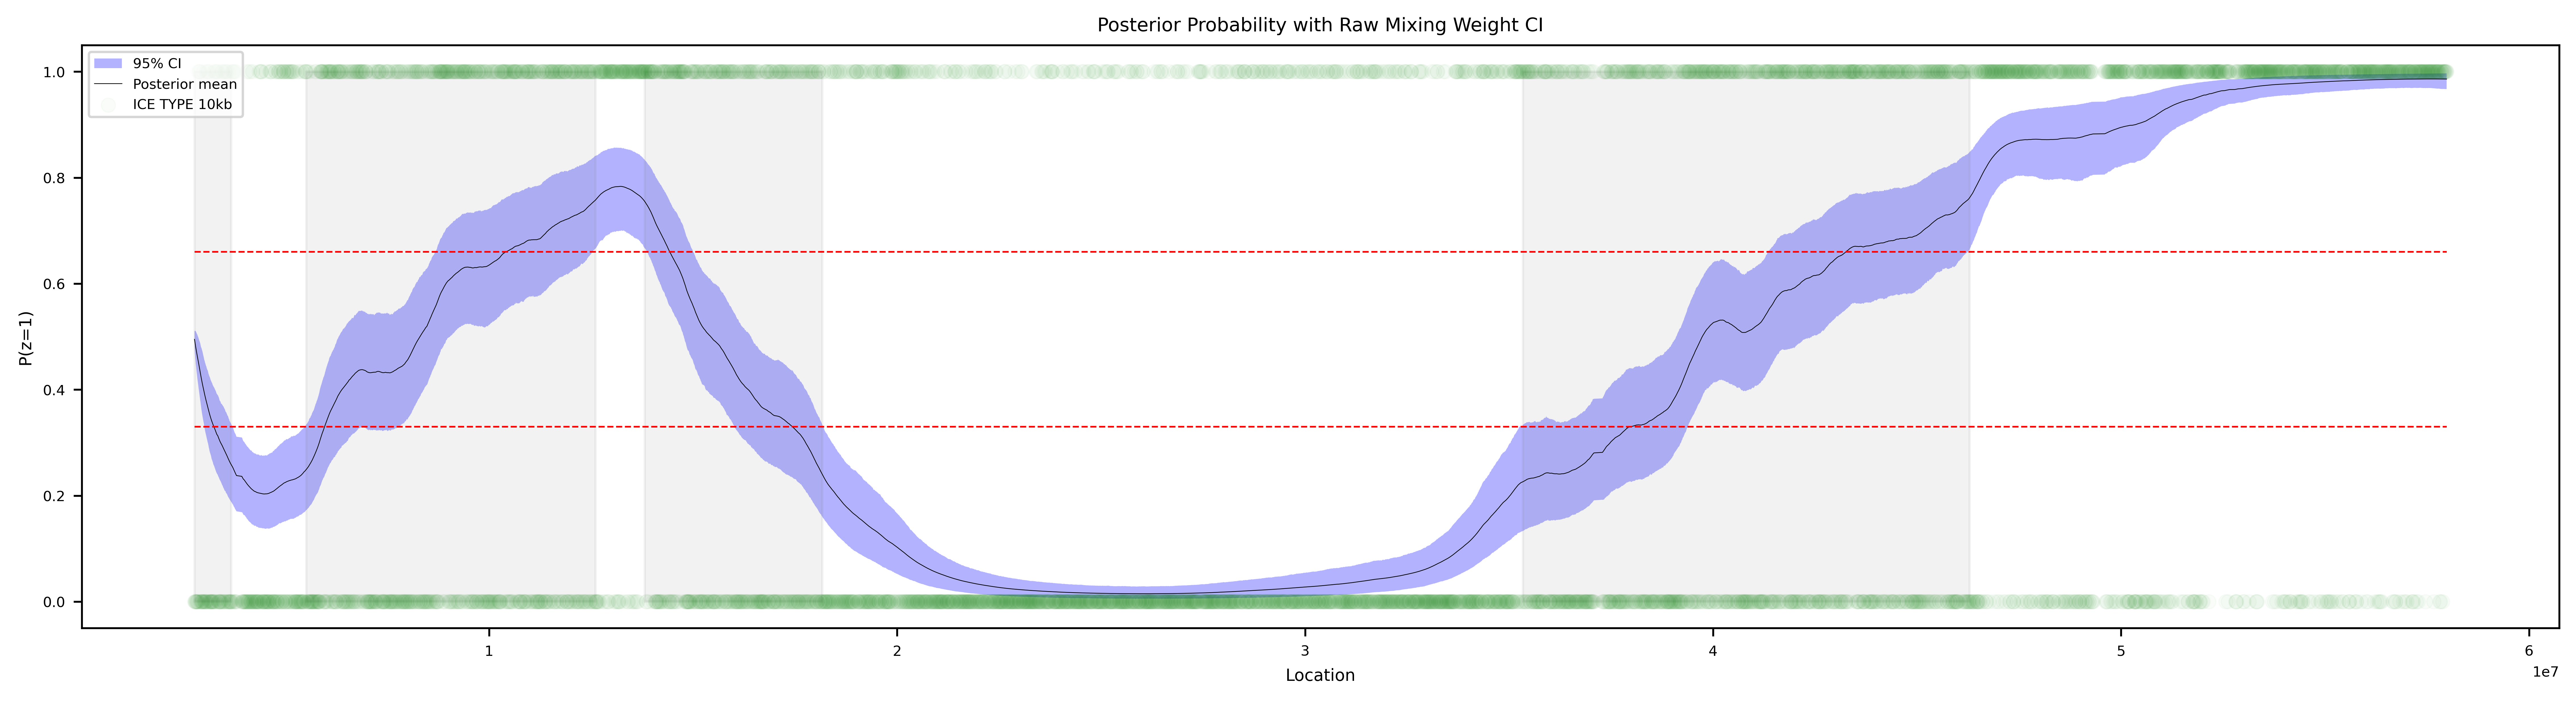

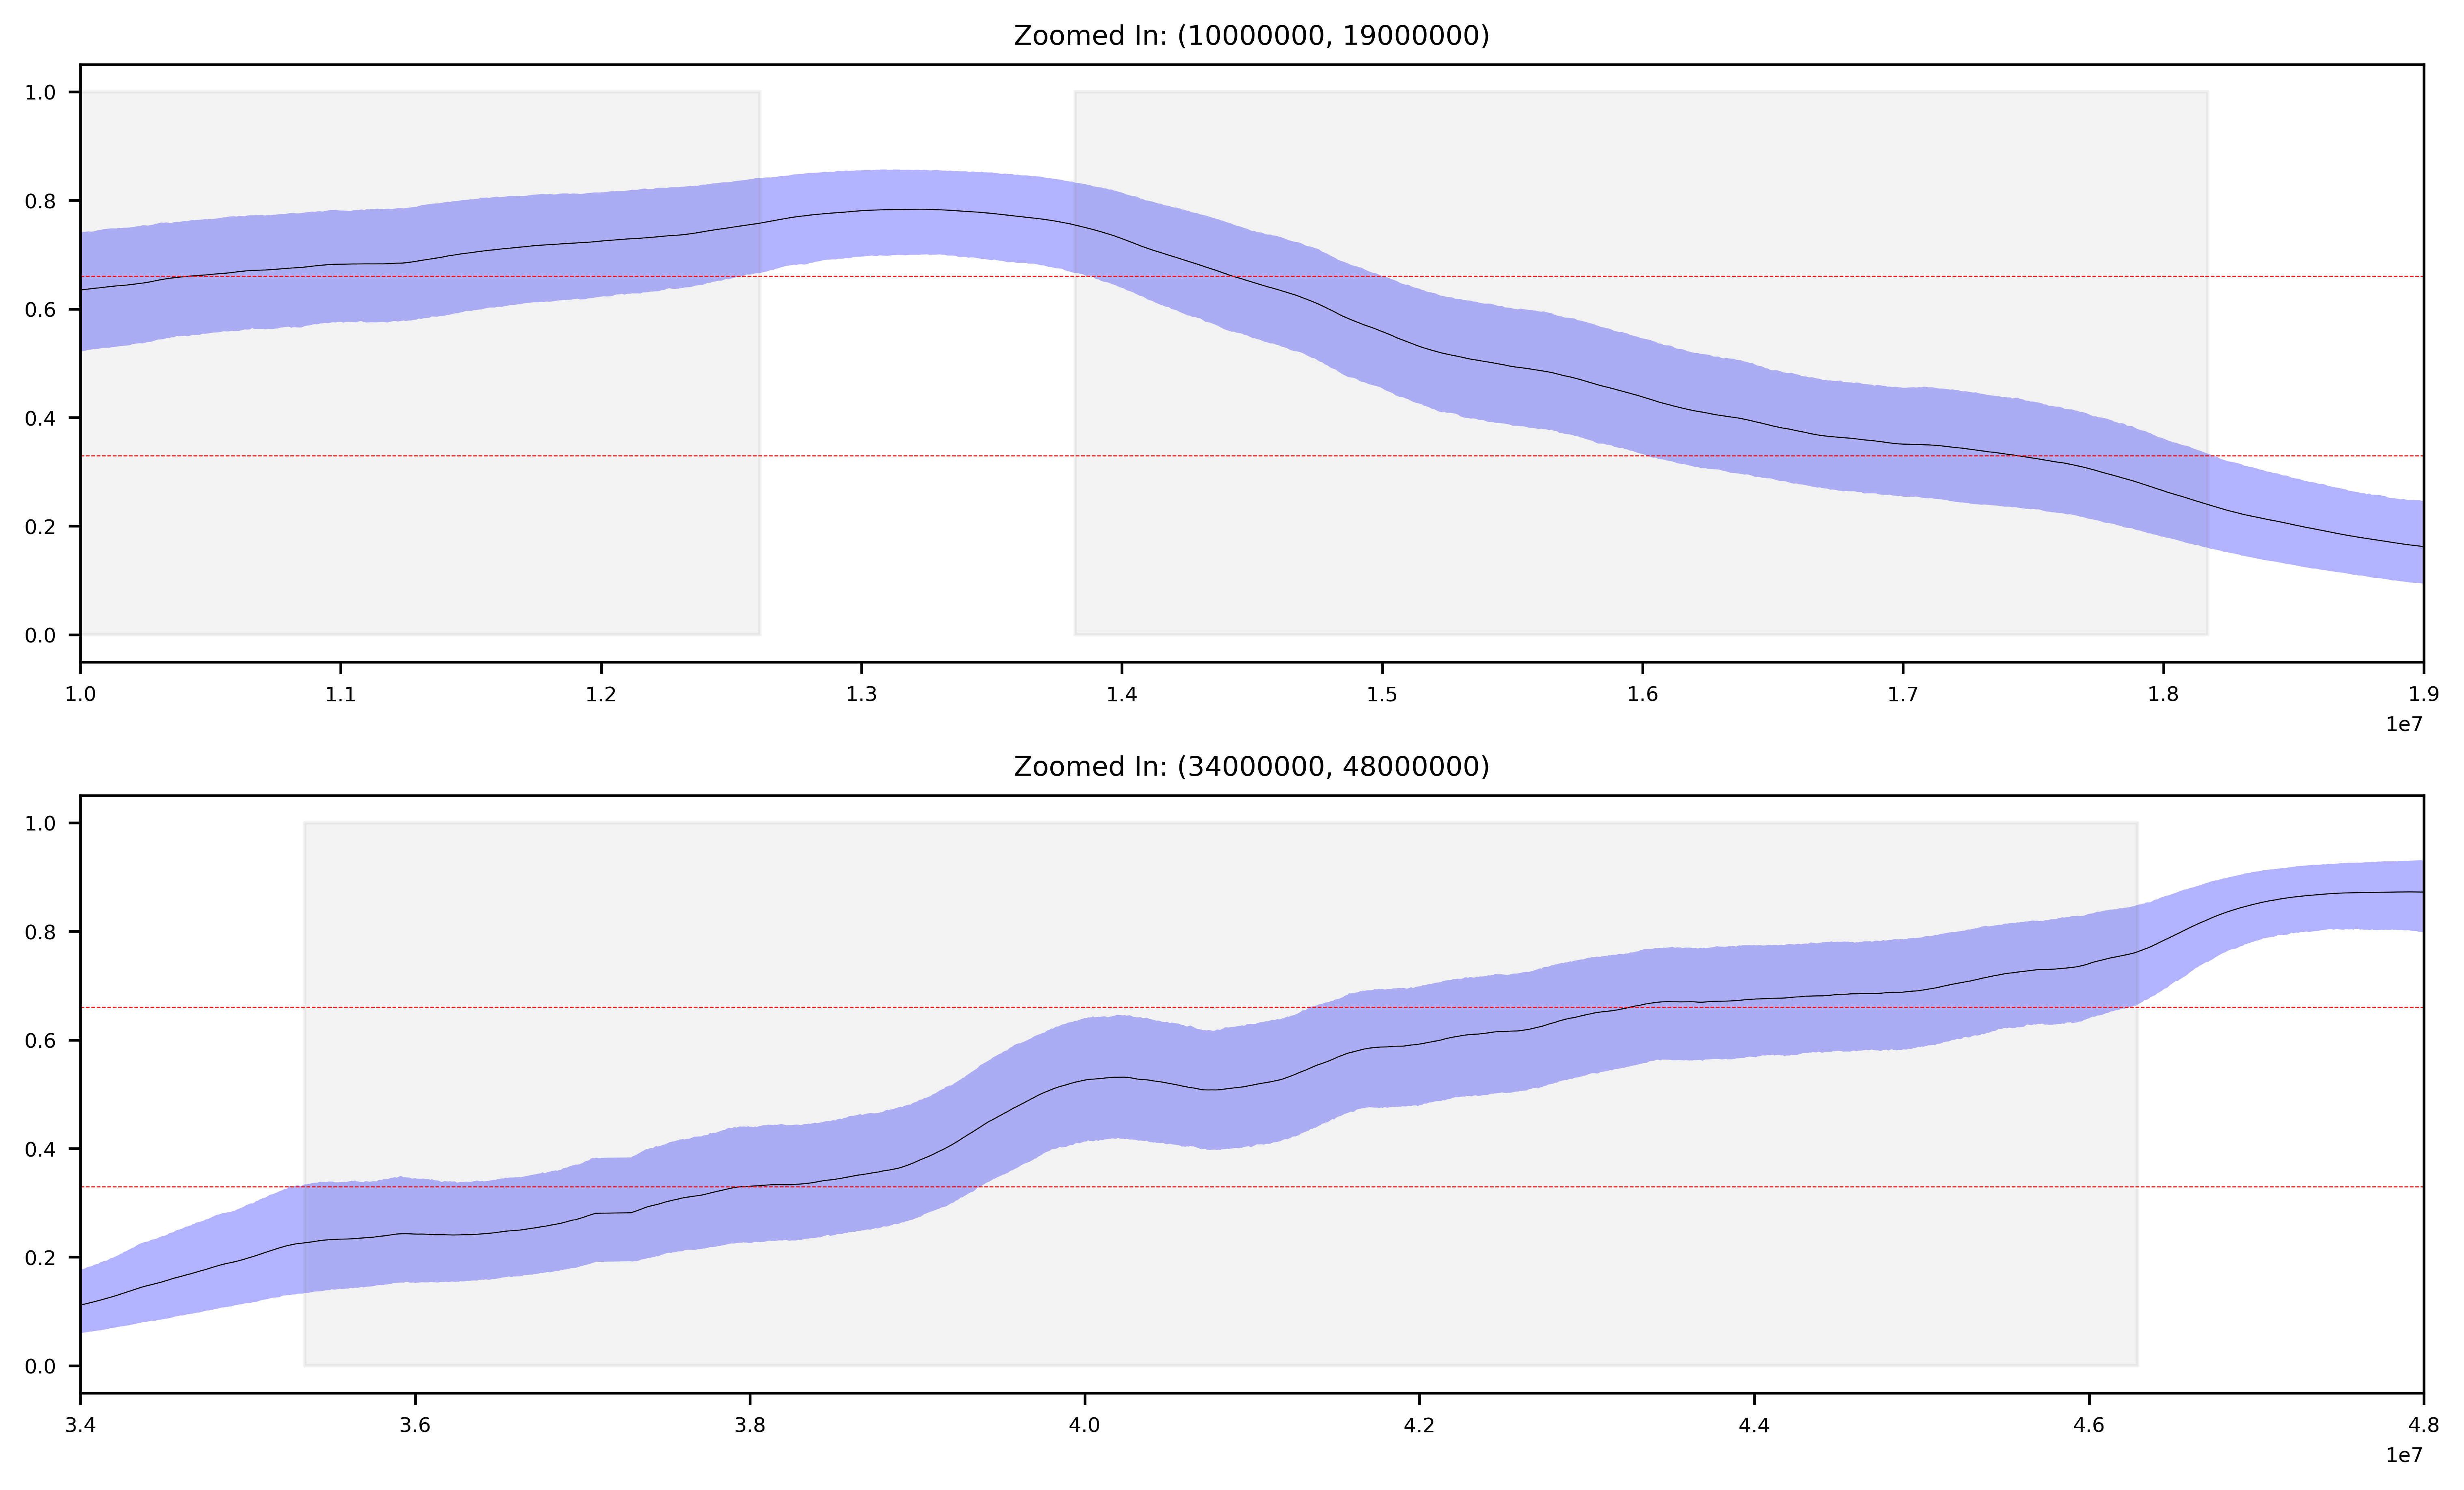

In [28]:
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png', dpi=600)

x = w_stack_z["pos"]*10000

f, ax = plt.subplots(figsize=(15, 4))

ax.fill_between(
    x,
    w_ci_lower_direct,
    w_ci_upper_direct,
    alpha=0.3,
    label="95% CI",
    color="blue",
    ec='None'
)

x_grey = x.copy()
x_grey = x_grey.where(
    ~((w_ci_lower_direct < 1/3) & (w_ci_upper_direct < 1/3) | (w_ci_lower_direct > 2/3) & (w_ci_upper_direct > 2/3)),
    np.nan
)

# Grey band
ax.fill_between(
    x, 
    0,
    1,
    where=x_grey.notnull(),
    alpha=0.1,
    color='gray')

# Compare e1 predictions
e1 = dfs['10kb'].query(q_small)
hard_assign =  e1.e1 > 0

ax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)

ax.scatter(e1.start, hard_assign, label="ICE TYPE 10kb", color="green", linewidth=0.5, alpha=0.025)

# Plot the 0.5 line
ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.7)

plt.ylabel("P(z=1)")
plt.xlabel("Location")
plt.legend(loc='upper left')
plt.title("Posterior Probability with Raw Mixing Weight CI")
# # plt#tight_layout()
plt.show()

zooms = [(10_000_000,19_000_000), (34_000_000, 48_000_000)]

f, axs = plt.subplots(len(zooms), figsize=(10, 3*len(zooms)))

for i, zoom in enumerate(zooms):
    zax = axs[i]
    zax.fill_between(
        x,
        w_ci_lower_direct,
        w_ci_upper_direct,
        alpha=0.3,
        color="blue",
        ec='None'
    )

    # Grey band
    zax.fill_between(
        x, 
        0,
        1,
        where=x_grey.notnull(),
        alpha=0.1,
    color='gray')

    zax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)
    zax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.3)
    zax.set_xlim(zoom)
    zax.set_title(f"Zoomed In: {zoom}")

# # plt#tight_layout()
plt.show()



So, how can we visualize the density of confidence band? 

I will try to plot all the curves with a very low alpha to see if it looks nice.

In [29]:
w_stack_z.isel(sample=slice(0,100))

<xarray.DataArray 'w' (pos: 5376, sample: 100)> Size: 4MB
array([[0.50855592, 0.47955529, 0.49533573, ..., 0.50887423, 0.49561875,
        0.49081788],
       [0.50099056, 0.47593478, 0.49390709, ..., 0.50987188, 0.48508137,
        0.49760707],
       [0.50069523, 0.46610216, 0.49810795, ..., 0.50616192, 0.47287862,
        0.50512636],
       ...,
       [0.98721082, 0.99587065, 0.98867181, ..., 0.99468793, 0.98276839,
        0.98935553],
       [0.98639584, 0.99611564, 0.98918505, ..., 0.99469591, 0.9830416 ,
        0.98928506],
       [0.98627243, 0.99615631, 0.98939814, ..., 0.99459059, 0.98169441,
        0.98963428]], shape=(5376, 100))
Coordinates:
  * pos      (pos) int64 43kB 278 279 280 281 282 ... 5794 5795 5796 5797 5798
  * sample   (sample) object 800B MultiIndex
  * chain    (sample) int64 800B 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
  * draw     (sample) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99

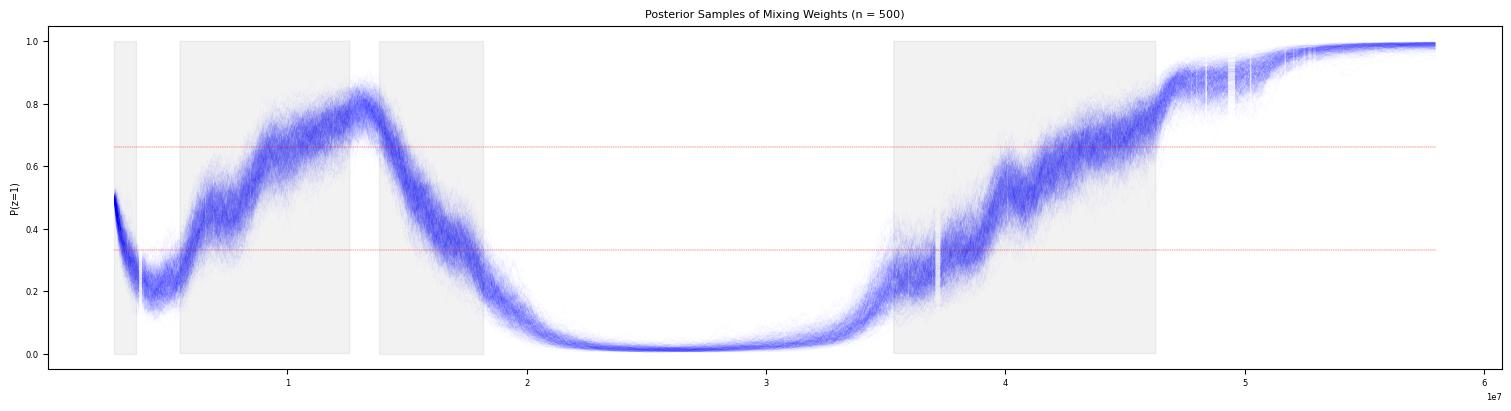

In [30]:
# Plot the all posterior samples of `w` in a single plot
# but start out with a smaller subset
# set the inline display to low dpi
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('jpg')

w_subset = w_stack_z.isel(sample=slice(0, 500))  # Adjust the slice as needed

f, ax = plt.subplots(figsize=(15, 4))

for i in range(w_subset.shape[1]):
    ax.plot(x, w_subset[:,i], alpha=0.1, linewidth=0.05, color="blue")

# Grey band
ax.fill_between(
    x, 
    0,
    1,
    where=x_grey.notnull(),
    alpha=0.1,
    color='gray')

ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.3)
ax.set_ylabel("P(z=1)")

plt.title(f"Posterior Samples of Mixing Weights (n = {w_subset.shape[1]})")
# # plt#tight_layout() # constrained: True is set in rcParams
plt.show()


## Translate into positional uncertainty

We translate the transitional regions (based on our CI rule) by counting the number of curves that cross the midpoint (0.5) between each position. Then we can summarize with statitics and establish the most likely transition. 

In [31]:
import numpy as np
import xarray as xr

w_np = w_stack_z.values  # Convert to numpy array
w_da = w_stack_z # Use the xarray DataArray directly


In [32]:
# Try again

mask = (w_np > 0.5)  # plain ndarray
mask_next = np.roll(mask, shift=-1, axis=0)  # Shift mask down by one position
mask_curr = mask[:, :]

print(mask_curr.shape)

cross_down = mask_curr & ~mask_next
cross_up = ~mask_curr & mask_next

# Or map the total crossings
crossings = mask_curr != mask_next

# Remove the last value where mask_next is wrapped from the first value
cross_down = cross_down[:-1, :]  # Remove the last row
cross_up = cross_up[:-1, :]  # Remove the last row
crossings = crossings[:-1, :]  # Remove the last row

# Sum the crossings across all samples to get the count of crossings at each position
crossing_counts = crossings.sum(axis=1)  # Sum across the sample dimension
cross_up_counts = cross_up.sum(axis=1)  # Sum across the sample dimension
cross_down_counts = cross_down.sum(axis=1)  # Sum across the sample dimension


# Calculate the density of crossings 
crossing_density = crossing_counts / w_np.shape[1]
crossing_density_up = cross_up_counts / w_np.shape[1]
crossing_density_down = cross_down_counts / w_np.shape[1]

# Print shapes of all
print("Shape of w_np, mask:", w_np.shape)
print("Shape of crossing_counts:", crossing_counts.shape)
print("Shape of crossing_density:", crossing_density.shape)
print("Shape of crossing_density_up:", crossing_density_up.shape)
print("Shape of crossing_density_down:", crossing_density_down.shape)




(5376, 7000)
Shape of w_np, mask: (5376, 7000)
Shape of crossing_counts: (5375,)
Shape of crossing_density: (5375,)
Shape of crossing_density_up: (5375,)
Shape of crossing_density_down: (5375,)


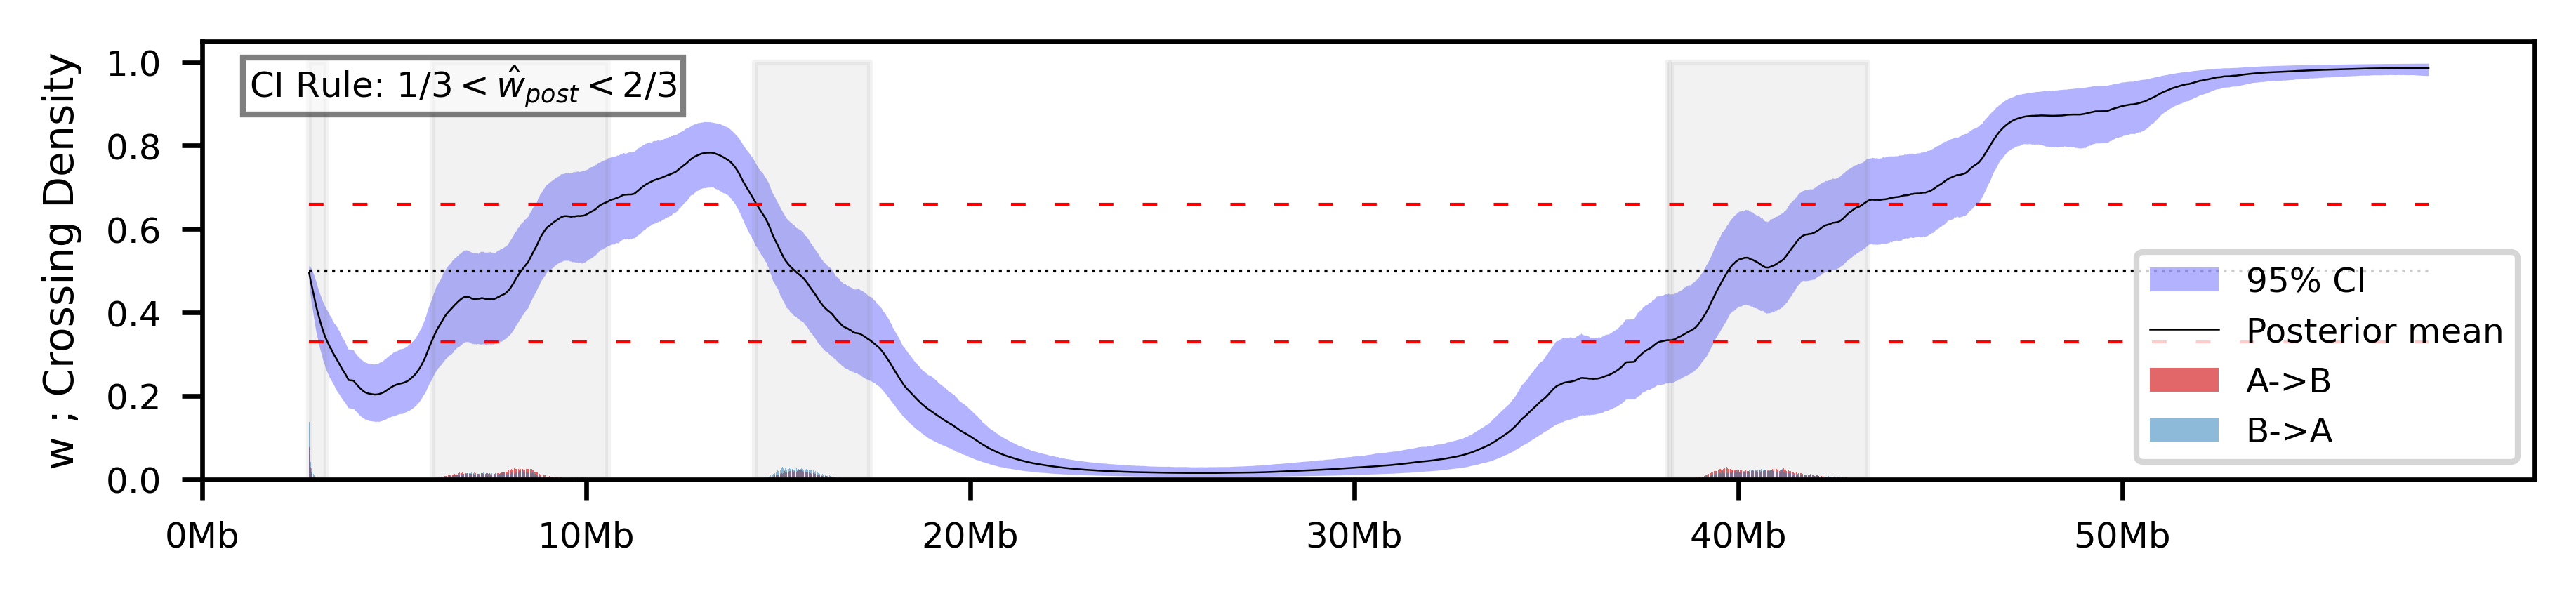

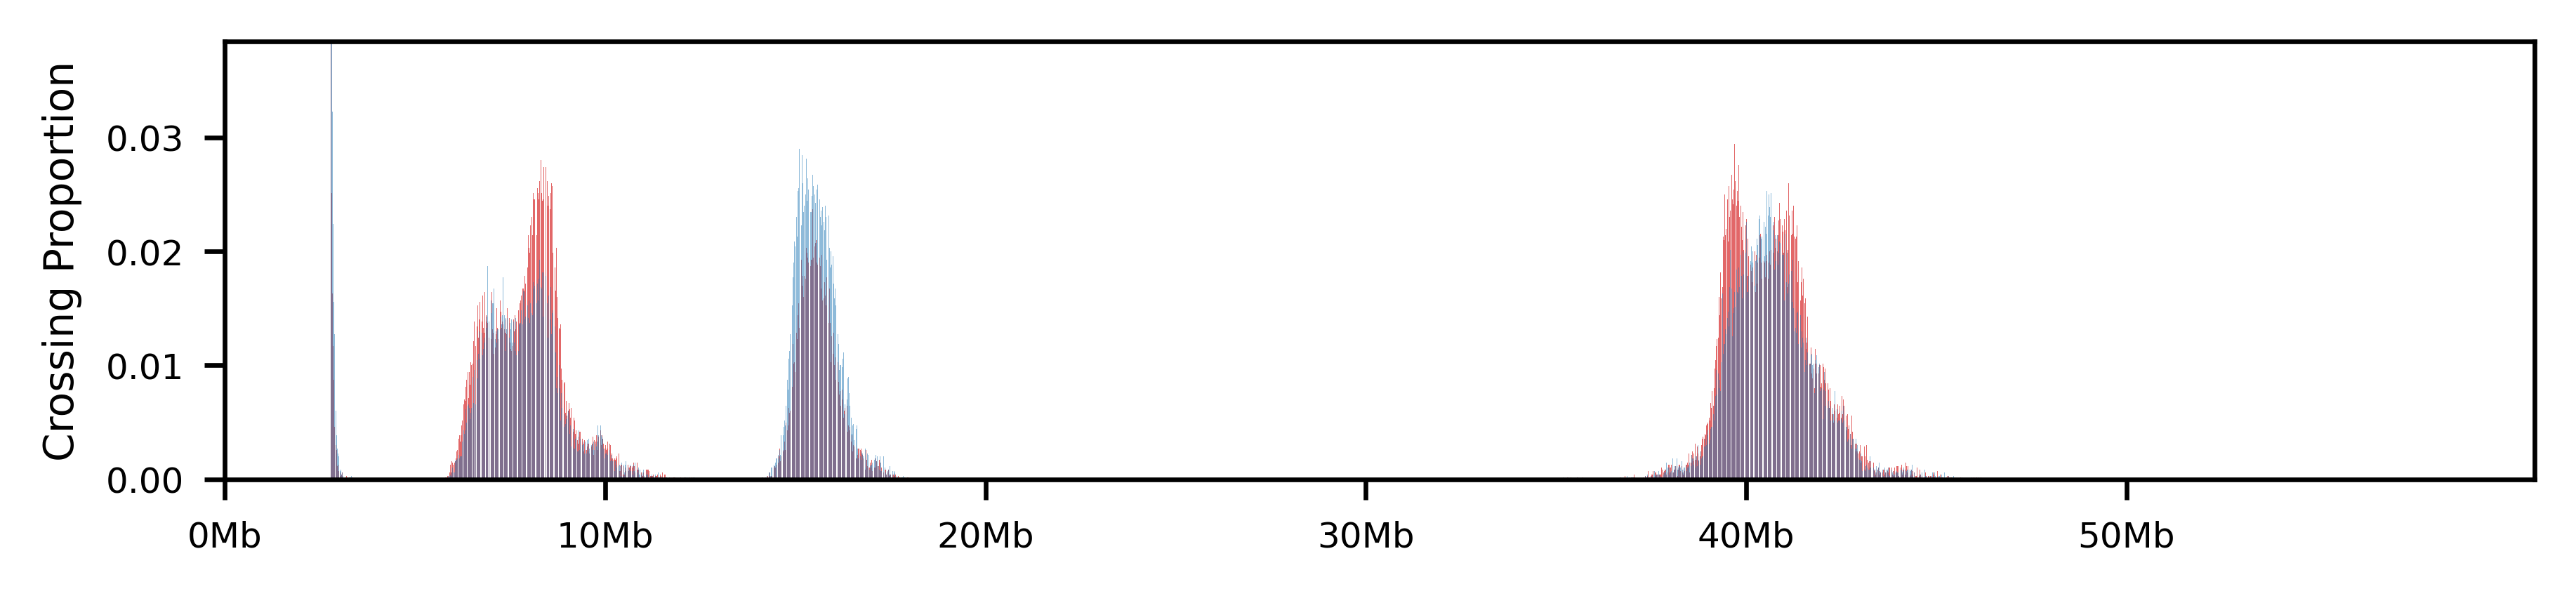

In [33]:
#| echo: false
#| label: "fig-hum-x-subset-posterior-cross-dens-ci-w"
#| fig-scap: Posterior Probability with Raw Mixing Weight CI and Crossing Density (Human X small-arm)
#| fig-cap: "Posterior Probability with Raw Mixing Weight CI and Crossing Density. The CI rule used is $1/3 < \\hat{w}_{post} < 2/3$, as shown. The grey band indicates the regions where the CI rule is not satisfied. The crossing density bars show the proportion of posterior draws that cross at 0.5, with red indicating crossings upwards and blue indicating crossings downwards."
#| fig-subcap:
#|  - "Posterior Probability with Raw Mixing Weight CI and Crossing Density"
#|  - "Crossing Density Only"
#| layout-ncol: 1

import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png', dpi=600)

x = w_stack_z["pos"]
figsize = (6,1.3)
f, ax = plt.subplots(figsize=figsize)

ax.fill_between(
    x,
    w_ci_lower_direct,
    w_ci_upper_direct,
    alpha=0.3,
    label="95% CI",
    color="blue",
    ec='None'
)

x_grey = x.copy()
x_grey = x_grey.where(
    ~((w_mean < 1/3) | (w_mean > 2/3)), np.nan
    #~((w_ci_lower_direct < 1/3) & (w_ci_upper_direct < 1/3) | (w_ci_lower_direct > 2/3) & (w_ci_upper_direct > 2/3)), np.nan
)

# Grey band
ax.fill_between(
    x, 
    0,
    1,
    where=x_grey.notnull(),
    alpha=0.1,
    color='gray')

# Add the CI rule as text
ax.text(0.02, 0.95, "CI Rule: $1/3 < \\hat{w}_{post} < 2/3$", 
        transform=ax.transAxes, fontsize=6, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5, pad=1))

# Plot the posterior mean
ax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)

# Plot the 0.5 line
ax.hlines(0.5, min(x), max(x), color="black", linestyle='dotted', linewidth=0.5)

# # Plot the CI rules
ax.hlines([0.33,0.66], min(x), max(x), color="red", linestyle=(0, (5, 10)), linewidth=0.5)

# Plot the crossing counts
ax.bar(x[:-1], crossing_density_up, label="A->B", color="tab:red", linewidth=0.3, alpha=0.7)
ax.bar(x[:-1], crossing_density_down, label="B->A", color="tab:blue", linewidth=0.3, alpha=0.5)

#  make x-axis tick x 10000 
ticks = np.arange(0, len(x), step=10*1e06/10000)
ax.set_xticks(ticks)
ticklabels = ax.set_xticklabels([f"{int(tick/100)}Mb" for tick in ticks])

plt.ylabel("w ; Crossing Density")
#plt.xlabel("Position (10kb bins)")
plt.legend(loc='lower right')
#plt.title("Posterior Probability with Raw Mixing Weight CI and Crossing Density")
# # plt#tight_layout()
plt.show()

## Now a new plot for only the crossing density

f, ax = plt.subplots(figsize=figsize)

ax.bar(x[:-1], crossing_density_up, label="A->B", color="tab:red", ec='None', linewidth=0, alpha=0.7)
ax.bar(x[:-1], crossing_density_down, label="B->A", color="tab:blue", ec='None', linewidth=0, alpha=0.5)

ax.set_ylim(0, np.quantile(crossing_density, 0.95))
# reuse ticks from previous plot
ax.set_xticks(ticks)
ax.set_xticklabels(ticklabels)
plt.ylabel("Crossing Proportion")
plt.show()


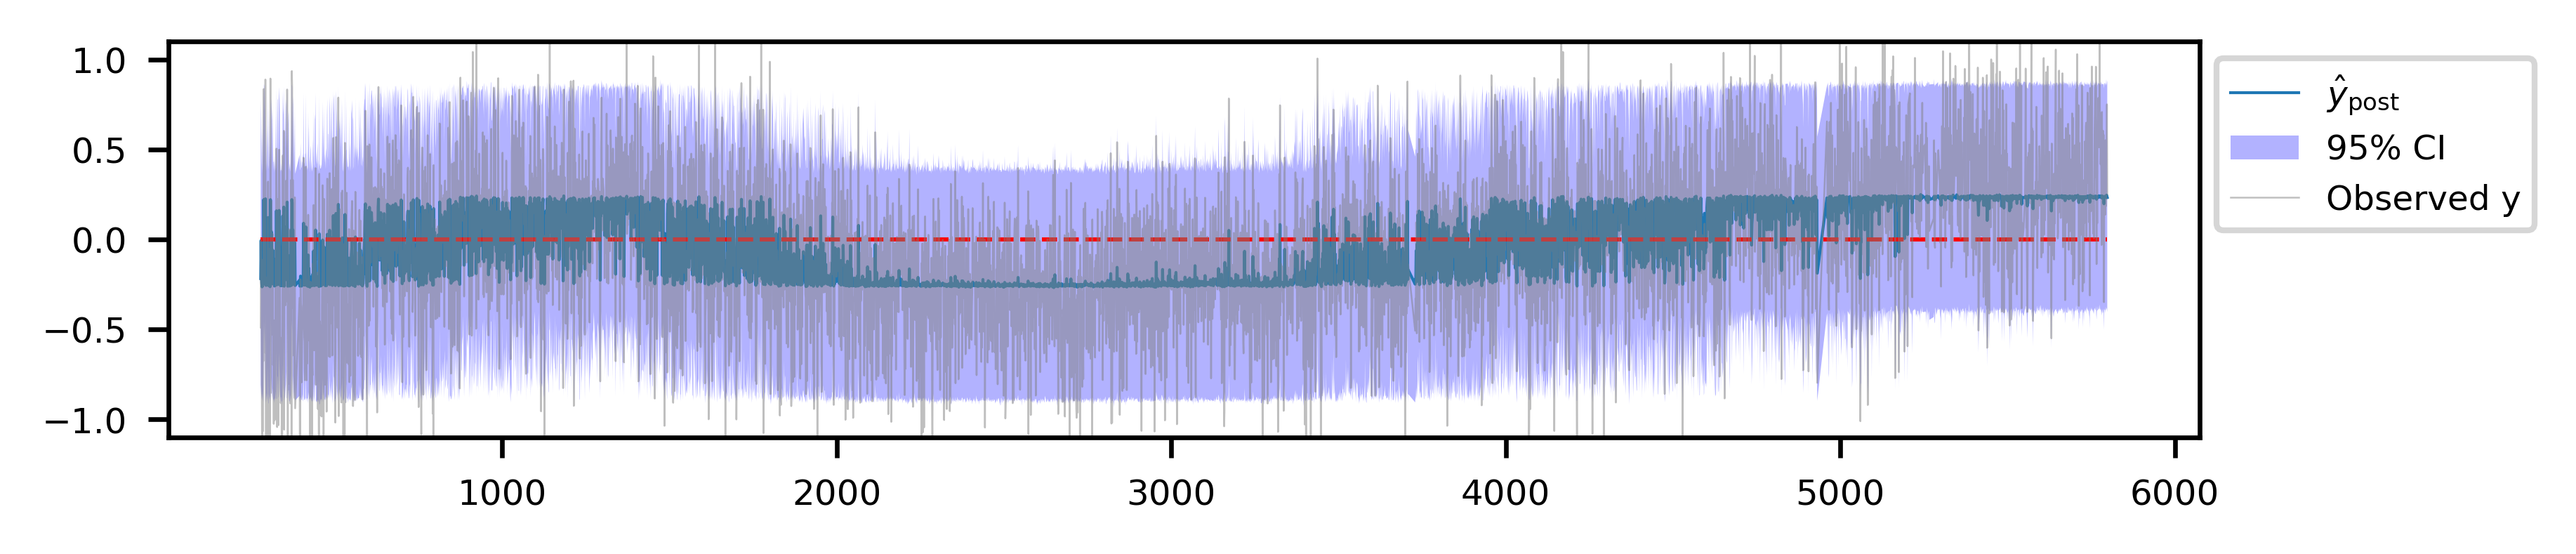

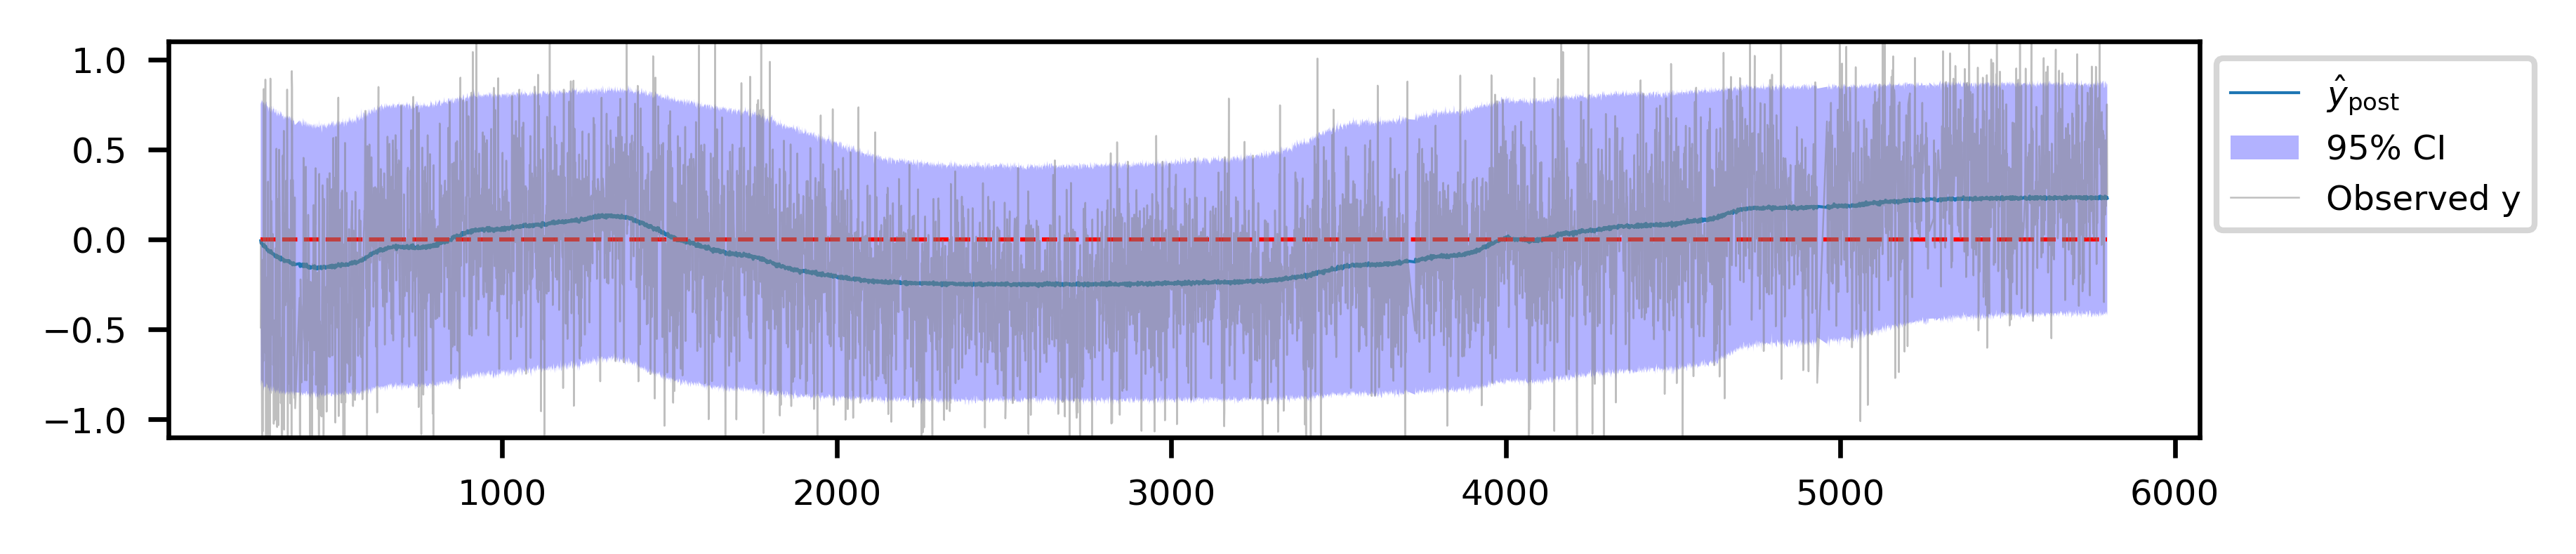

In [34]:
#| echo: false
#| label: "fig-hum-x-subset-ppc-trace-w-z-compare"
#| fig-cap: "ChrX Posterior Predictive Check for X-bearing sperm ($\\widehat{E1}$) for both the Z and W models. The posterior mean is shown as a blue line, with the 95% credible interval shaded in blue. The observed E1 values are shown in gray."
#| fig-subcap: 
#|  - Discrete model
#|  - Continuous (mixture) model
#| fig-scap: "ChrX Posterior Predictive trace for human sperm for Z and W models."
#| layout-ncol: 1

import matplotlib.pyplot as plt
 
traces = {
    'trace_z': trace_z,
    'trace_w': trace_w
}

for name, trace in traces.items():
    yhat_mean = trace.posterior_predictive.y_hat.mean(dim=('chain', 'draw'))
    yhat_upper = trace.posterior_predictive.y_hat.quantile(0.975, dim=('chain', 'draw'))
    yhat_lower = trace.posterior_predictive.y_hat.quantile(0.025, dim=('chain', 'draw'))

    f,ax = plt.subplots(figsize=(6, 1.2))

    ax.plot(yhat_mean['pos'],yhat_mean, label=r"$\hat{y}_{\mathrm{post}}$", linewidth=0.5)
    ax.hlines(0, min(yhat_mean['pos']), max(yhat_mean['pos']), color='red', linestyle='--', linewidth=0.7)

    ax.fill_between(yhat_mean['pos'], 
                    yhat_upper,
                    yhat_lower,
                    alpha=0.3, label="95% CI", color='blue', ec='None')

    ax.plot(trace.observed_data.y_hat['pos'], trace.observed_data.y_hat, alpha=0.5, color='gray', linewidth=0.3, label="Observed y")
    ax.set_ylim(-1.1, 1.1)

    # plt.title("Posterior Predictive Check for X-bearing sperm ($\\widehat{E1}$) " + f"`{name}`") # remove when using YAML fig-cap
    # Move the legend outside of the plot (right hand side)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    # # plt#tight_layout()



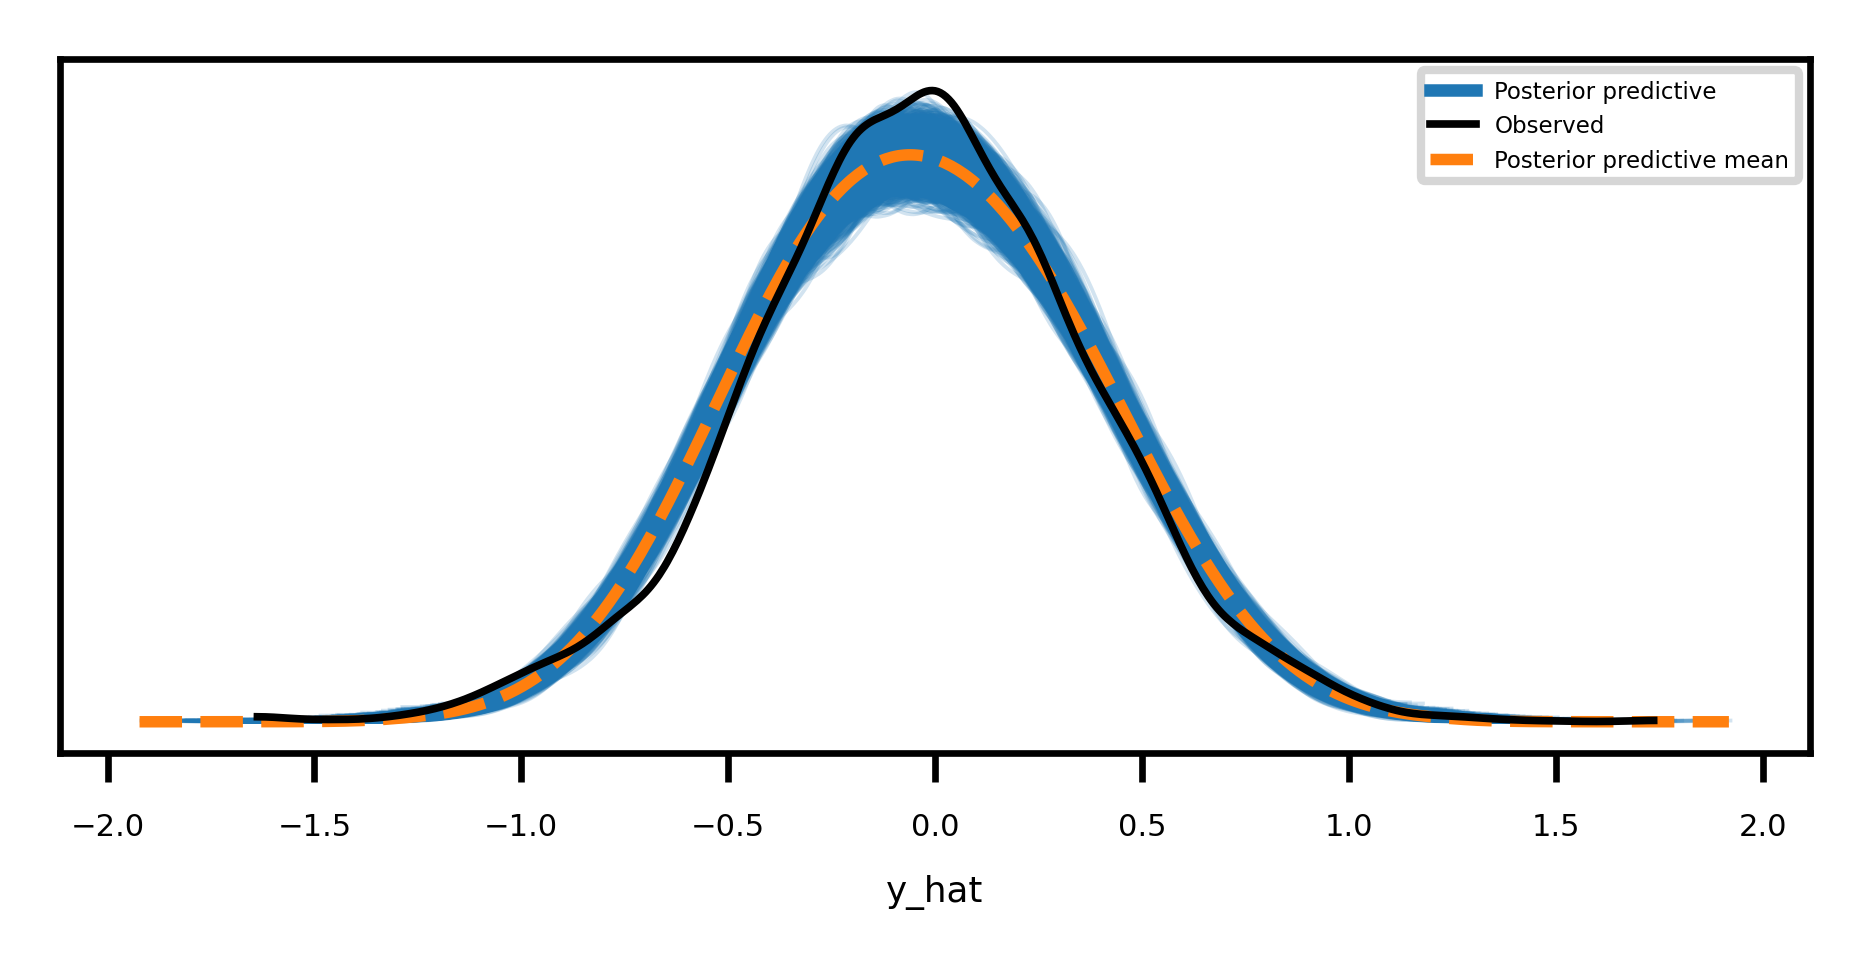

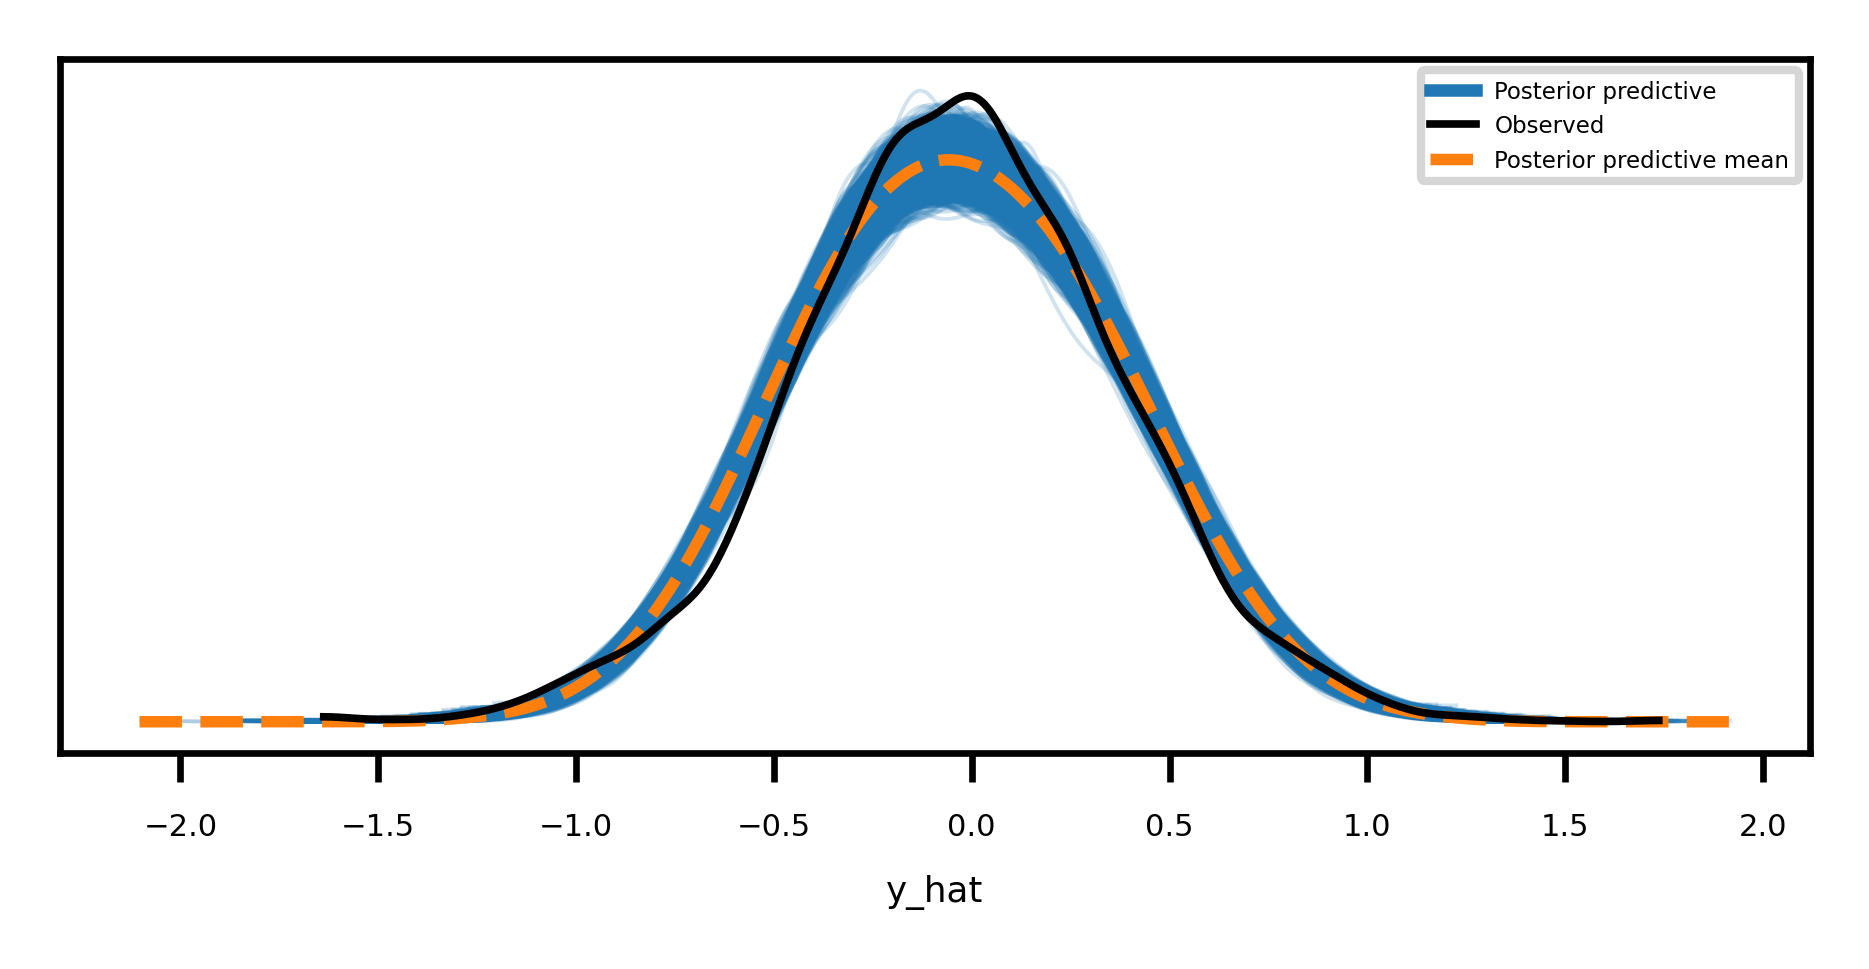

In [35]:
#| echo: false
#| label: "fig-hum-x-subset-ppc-dist-w-z-compare"
#| fig-cap: "ChrX Posterior Predictive Check Distribution for X-bearing sperm ($\\widehat{E1}$) for both the Z and W models. The posterior predictive distribution is shown in blue, the predictive mean in dashed orange, and the observed E1 distribution in black."
#| fig-scap: "ChrX Posterior Predictive Distribution for human sperm Z and W models"
#| fig-subcap:
#|  - Discrete model (`Z`)
#|  - Continuous (mixture) model (`W`)
#| layout-ncol: 2

az.plot_ppc(trace_z, figsize=(3, 1.5))
plt.show()
az.plot_ppc(trace_w, figsize=(3, 1.5))
plt.show()